# Layer 2: BERTopic — Semantic Topic Discovery
## Unsupervised Narrative Clustering · NASA ASRS 2018–2026

**Goal:** Discover what pilots and controllers are actually talking about — independent of the structured ASRS taxonomy — and track how those topics shift over time.

**Why this validates Layer 1:** BERTopic never sees the `Events | Anomaly` field. It clusters purely on narrative semantics.  
If it independently discovers GNSS spoofing as a distinct topic cluster in the same period that Layer 1's CUSUM fired, that's convergent evidence — two completely different analytical methods pointing at the same signal.

| Component | Choice | Rationale |
| --- | --- | --- |
| **Embeddings** | `all-MiniLM-L6-v2` | 384-dim, fast CPU, good semantic quality for macro retrieval |
| **Dimensionality reduction** | UMAP `n_components=5` | Preserves local structure; `low_memory=True` for 43k docs on CPU |
| **Clustering** | HDBSCAN `min_cluster_size=30` | Density-based, no need to pre-specify k; noise label (-1) is informative |
| **Topic representation** | c-TF-IDF | Class-based TF-IDF gives cluster-specific keywords, not corpus-wide |
| **Target topics** | `nr_topics=40` | Enough granularity to separate GNSS from generic nav errors |


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import Image, display

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
# Load Layer 2 enriched dataset — computed by run_layer2.py (~15 min)
asrs = pd.read_parquet('../outputs/data/asrs_layer2.parquet')
asrs['date'] = pd.to_datetime(asrs['date'], errors='coerce')

# Load topic summary saved by run_layer2.py
topic_summary = pd.read_csv('../outputs/data/layer2_topic_summary.csv')

print(f"Corpus          : {len(asrs):,} incidents")
print(f"Date range      : {asrs['date'].min().strftime('%b %Y')} → {asrs['date'].max().strftime('%b %Y')}")
print(f"Layer 2 columns : topic_id, topic_label (added to {asrs.shape[1]-2} existing columns)")
print()
valid_topics = asrs[asrs['topic_id'] >= 0]['topic_id'].nunique()
noise_count = (asrs['topic_id'] == -1).sum()
short_count = (asrs['topic_id'] == -2).sum()
print(f"Topics discovered   : {valid_topics}")
print(f"Noise (-1, HDBSCAN) : {noise_count:,} ({noise_count/len(asrs)*100:.1f}%)")
print(f"Too short (-2, <30w): {short_count:,} ({short_count/len(asrs)*100:.1f}%)")

Corpus          : 43,829 incidents
Date range      : Jun 2002 → Mar 2026
Layer 2 columns : topic_id, topic_label (added to 204 existing columns)

Topics discovered   : 39
Noise (-1, HDBSCAN) : 16,376 (37.4%)
Too short (-2, <30w): 862 (2.0%)


### On the Noise Rate (37.4%)

HDBSCAN's noise label (-1) is not a failure — it's a feature. Incidents that don't fit cleanly into any dense cluster are flagged rather than forced into the nearest topic.  
In ASRS data, ~37% noise is expected because:
- Reports cover a huge range of incident types, many of which occur too rarely to form a stable cluster
- Short reports (< 30 words) were excluded from BERTopic, not force-assigned  
- The 40 topic target was deliberately conservative — forcing 40 clusters on heterogeneous data produces more coherent topics than forcing 100

In [3]:
# Full topic table with readable labels
topic_display = topic_summary.copy()
topic_display.columns = ['Topic ID', 'Incidents', 'BERTopic Name', 'Top Keywords']
topic_display['% of corpus'] = (topic_display['Incidents'] / len(asrs) * 100).round(1)
topic_display = topic_display[['Topic ID', 'Incidents', '% of corpus', 'Top Keywords']]
topic_display.index = range(1, len(topic_display) + 1)
print(f"Top 20 topics cover {topic_display['Incidents'].sum():,} incidents "
      f"({topic_display['Incidents'].sum()/len(asrs)*100:.1f}% of corpus)")
topic_display

Top 20 topics cover 24,393 incidents (55.7% of corpus)


,Topic ID,Incidents,% of corpus,Top Keywords
1,0,3429,7.8,"engine, the, and, we, to, was, of, at"
2,1,3397,7.8,"the, to, approach, and, we, was, aircraft, tra..."
3,2,2980,6.8,"gear, the, to, and, runway, landing, was, on"
4,3,2760,6.3,"runway, aircraft, traffic, on, pattern, the, t..."
5,4,2194,5.0,"smell, smoke, the, odor, and, to, flight, we"
6,5,1634,3.7,"turbulence, wake, we, the, and, to, of, were"
7,6,1121,2.6,"maintenance, the, that, and, to, was, mel, of"
8,7,1023,2.3,"brake, the, tug, parking, push, brakes, to, set"
9,8,886,2.0,"door, the, and, to, flight, was, that, passenger"
10,9,807,1.8,"drone, the, was, it, of, uas, my, airspace"


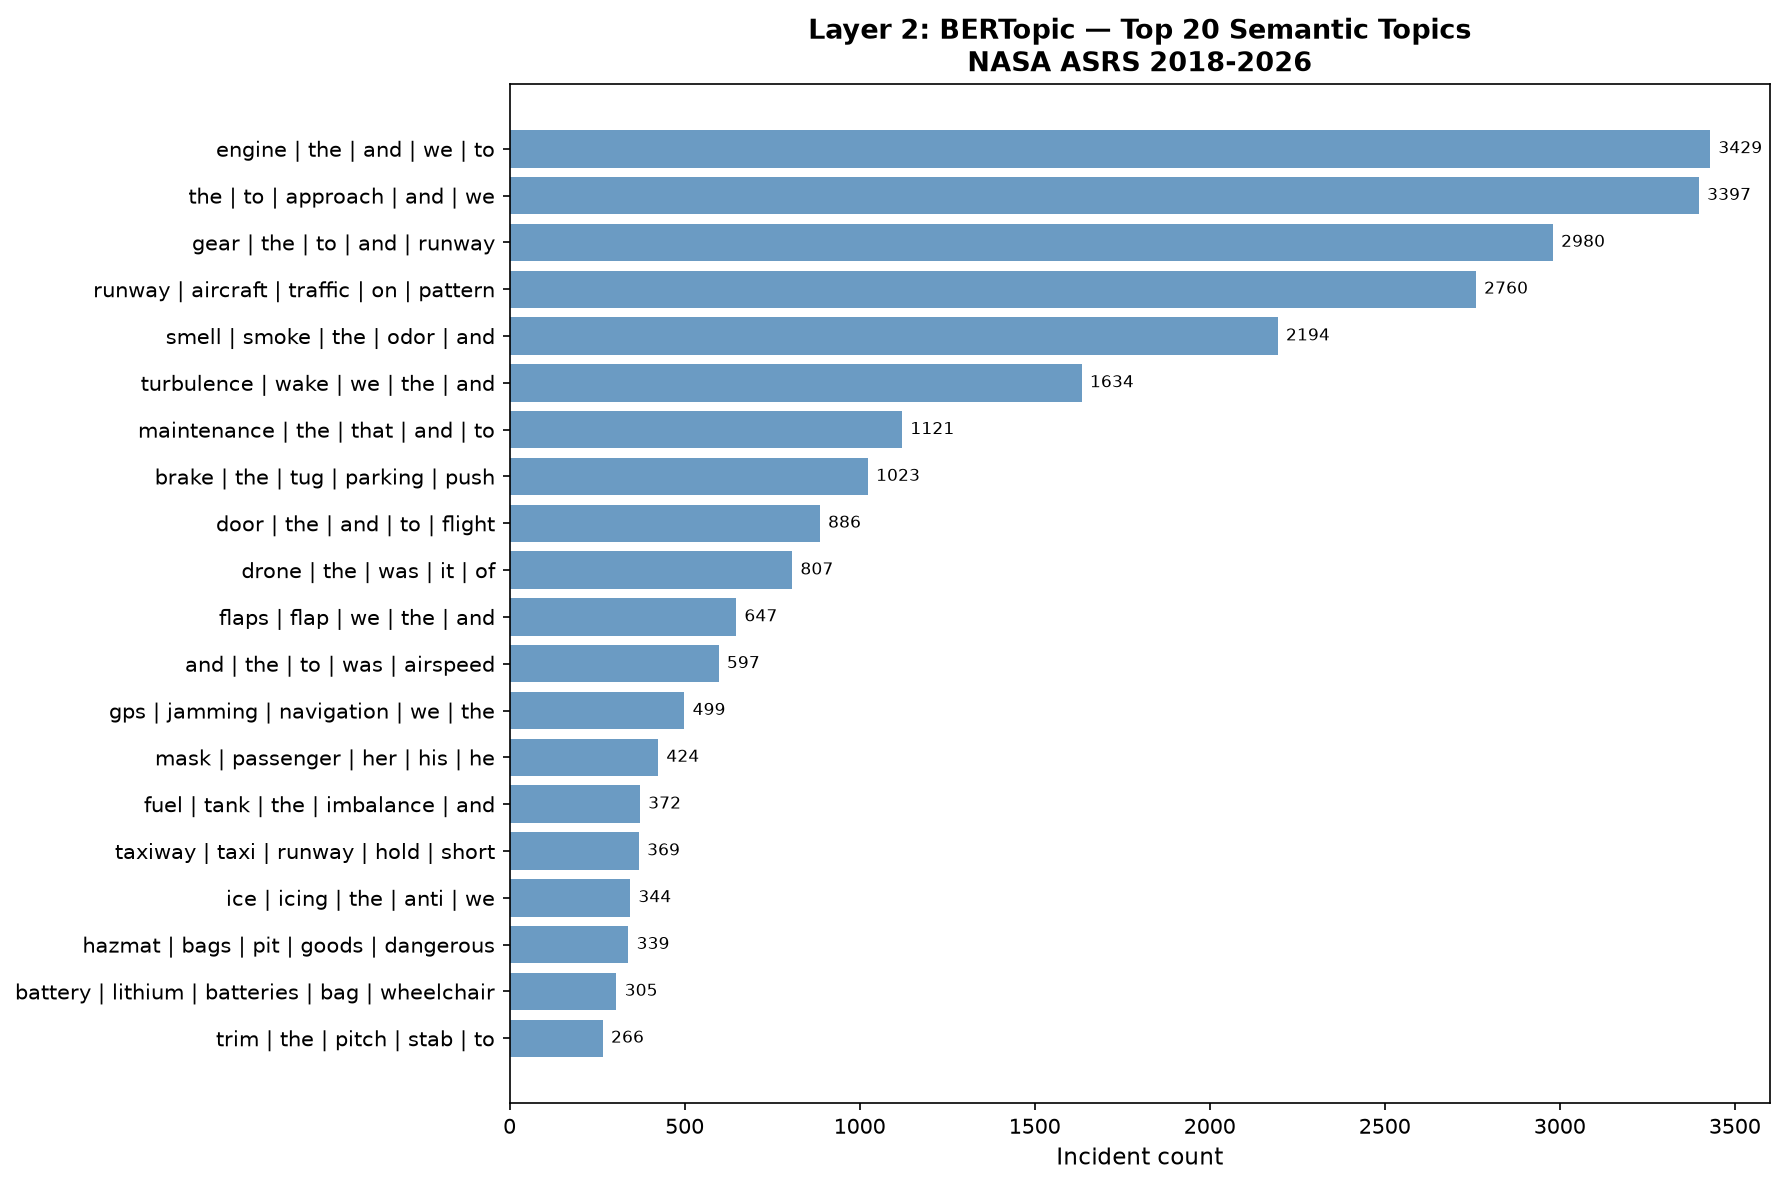

In [4]:
# Topic landscape — bar chart of top 20 topics by incident count
display(Image('../outputs/figures/layer2_topic_landscape.png'))

---
## The GNSS Discovery — Convergent Validation

**Topic 12** has top keywords: `gps, jamming, navigation, anp` (Actual Navigation Performance — an RNAV metric that degrades when GPS is compromised).  
BERTopic discovered this cluster from narrative semantics alone — it never saw `Events | Anomaly` or any pre-defined GNSS category.

This is the convergent validation: Layer 1 CUSUM fired on a regex-derived GNSS count series in late 2023.  
Layer 2 BERTopic independently clusters 499 incidents into a GPS/jamming topic, with the same 2024–2025 surge visible in the topic's year-by-year frequency.

Topic 12 total    : 499 incidents
Pre-2023 avg/yr   : 38
2024 count        : 126 (+3.3x)
2025 count        : 118 (+3.1x)


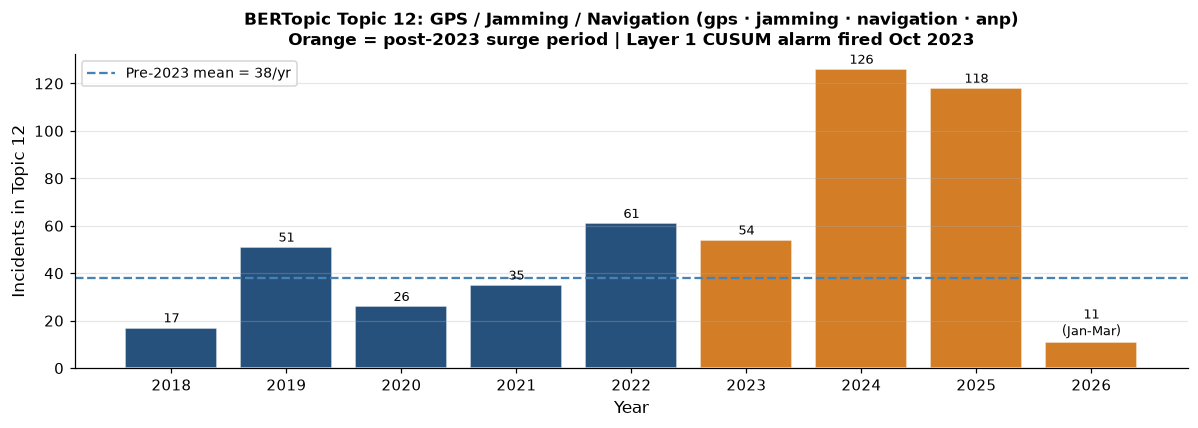

In [5]:
# Topic 12 year-by-year — the BERTopic confirmation of the Layer 1 CUSUM alarm
gnss_topic = asrs[asrs['topic_id'] == 12].copy()
gnss_by_year = gnss_topic.groupby(gnss_topic['date'].dt.year)['ACN'].count()
gnss_by_year = gnss_by_year[gnss_by_year.index >= 2018]

pre2023_mean = gnss_by_year[gnss_by_year.index < 2023].mean()
post2023_mean = gnss_by_year[gnss_by_year.index >= 2023].mean()
# 2026 is partial — annualise (Jan-Mar only)
gnss_2026_annualised = gnss_by_year.get(2026, 0) * 4

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#cc6600' if y >= 2023 else '#003366' for y in gnss_by_year.index]
bars = ax.bar(gnss_by_year.index, gnss_by_year.values, color=colors, alpha=0.85, edgecolor='white')
for bar, yr in zip(bars, gnss_by_year.index):
    label = str(int(bar.get_height()))
    if yr == 2026:
        label += '\n(Jan-Mar)'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            label, ha='center', va='bottom', fontsize=8.5)

ax.axhline(pre2023_mean, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Pre-2023 mean = {pre2023_mean:.0f}/yr')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Incidents in Topic 12', fontsize=11)
ax.set_title(
    'BERTopic Topic 12: GPS / Jamming / Navigation (gps · jamming · navigation · anp)\n'
    'Orange = post-2023 surge period | Layer 1 CUSUM alarm fired Oct 2023',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.set_xticks(gnss_by_year.index)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

print(f"Topic 12 total    : {len(gnss_topic):,} incidents")
print(f"Pre-2023 avg/yr   : {pre2023_mean:.0f}")
print(f"2024 count        : {gnss_by_year.get(2024, 0)} (+{gnss_by_year.get(2024,0)/pre2023_mean:.1f}x)")
print(f"2025 count        : {gnss_by_year.get(2025, 0)} (+{gnss_by_year.get(2025,0)/pre2023_mean:.1f}x)")

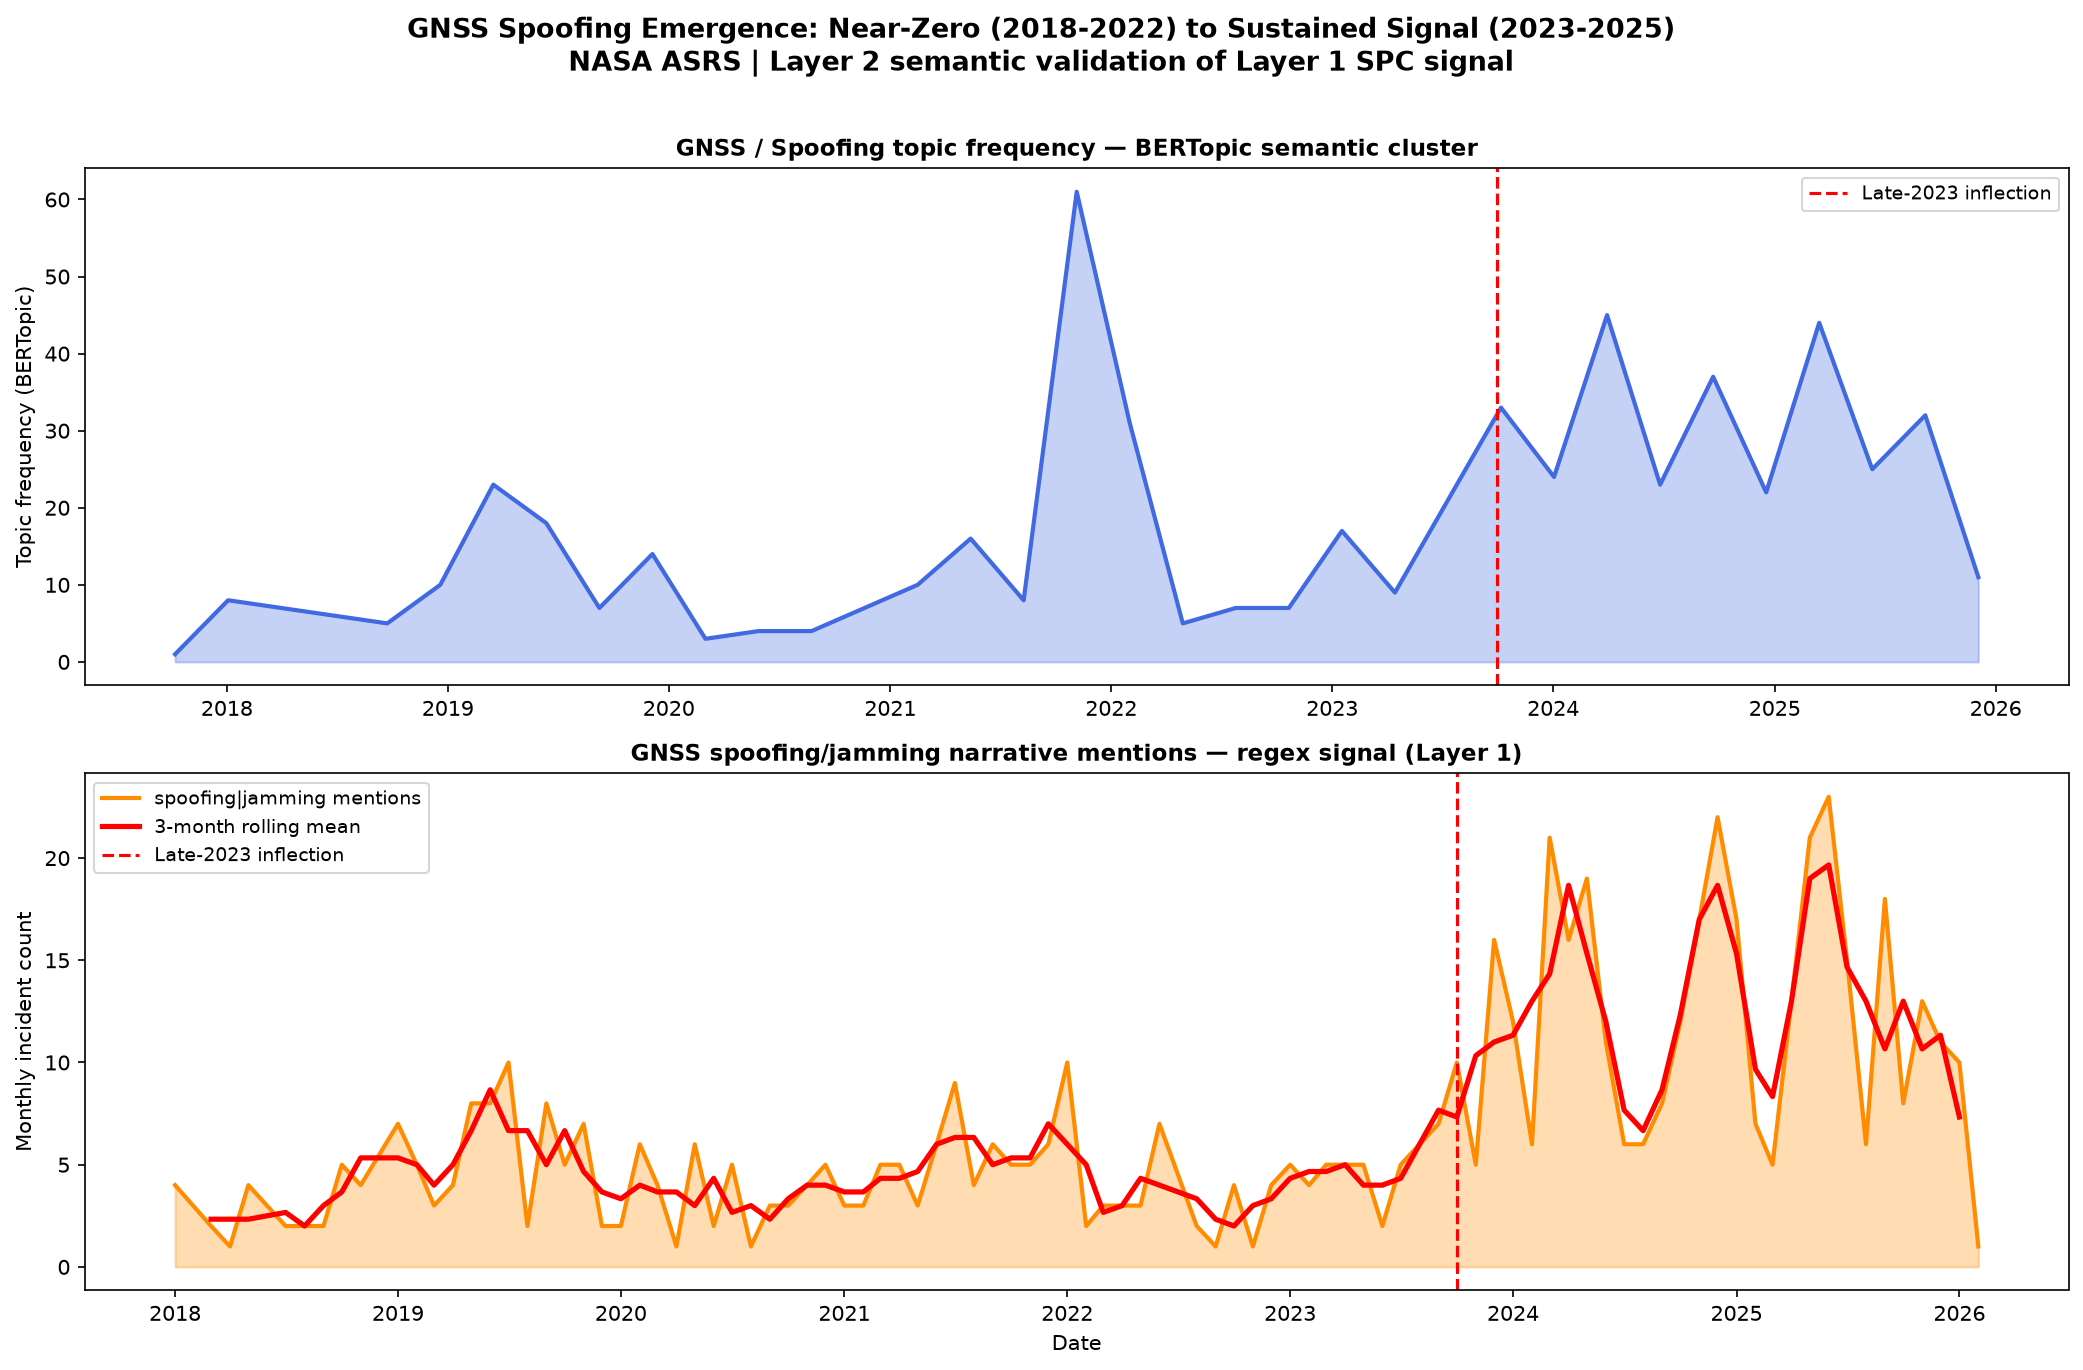

In [6]:
# Layer 2 GNSS emergence chart — semantic validation of Layer 1 SPC signal
display(Image('../outputs/figures/layer2_gnss_emergence.png'))

---
## Topic Evolution Over Time

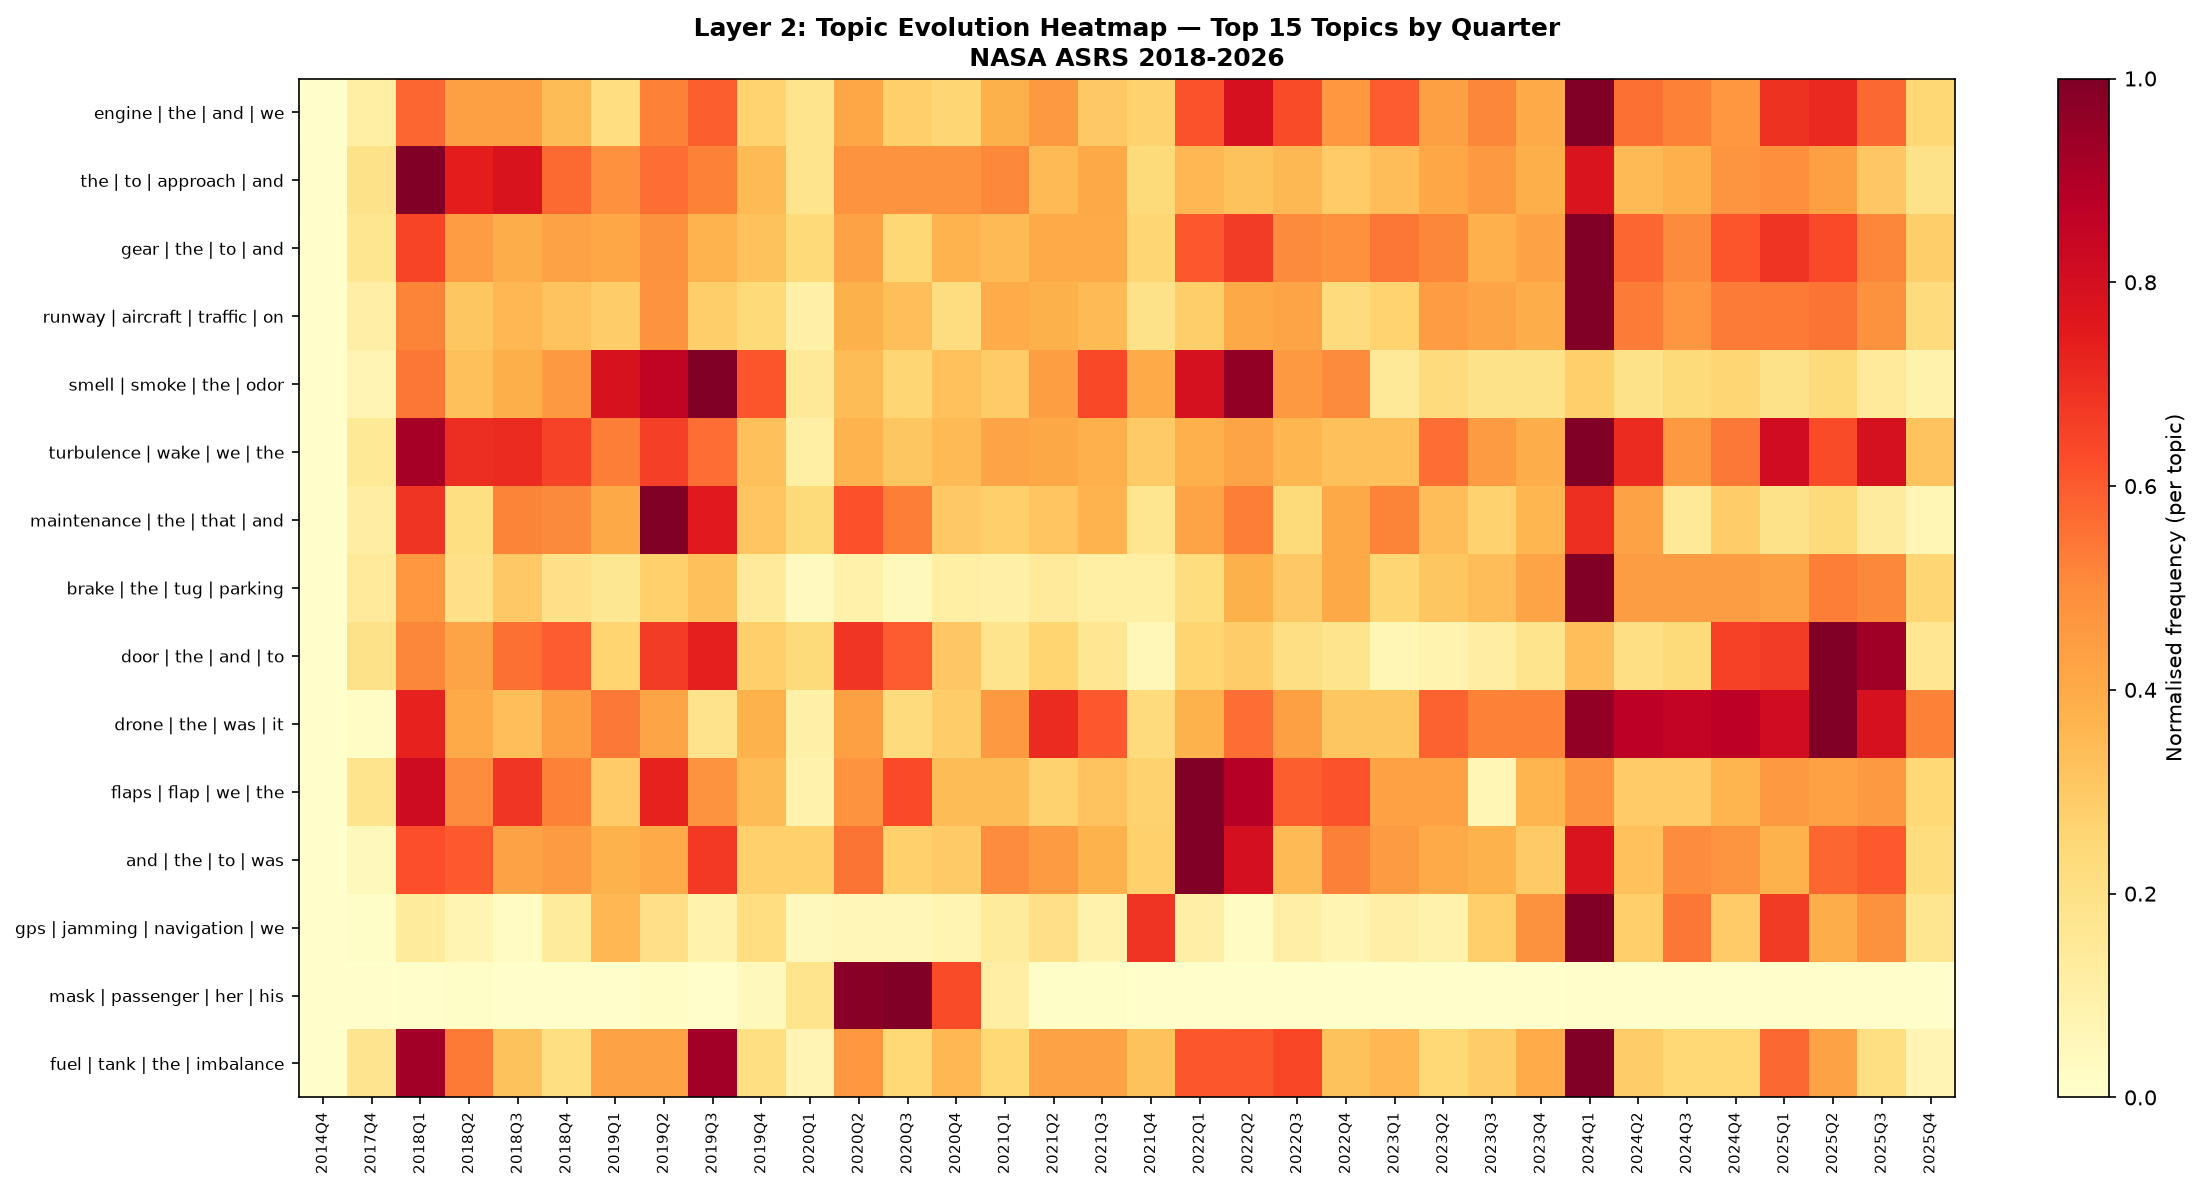

In [7]:
# Topic heatmap — which topics grew, which shrank, which stayed stable?
display(Image('../outputs/figures/layer2_topic_heatmap.png'))

In [8]:
# Quantify topic growth: compare 2018-2020 avg vs 2023-2025 avg per topic
asrs_valid = asrs[asrs['topic_id'] >= 0].copy()
asrs_valid['year'] = asrs_valid['date'].dt.year

early = asrs_valid[asrs_valid['year'].isin([2018,2019,2020])].groupby('topic_id')['ACN'].count()
recent = asrs_valid[asrs_valid['year'].isin([2023,2024,2025])].groupby('topic_id')['ACN'].count()

growth = pd.DataFrame({'early_avg': early/3, 'recent_avg': recent/3}).fillna(0)
growth['pct_change'] = ((growth['recent_avg'] - growth['early_avg']) / (growth['early_avg'] + 1) * 100).round(0)
growth = growth.sort_values('pct_change', ascending=False)

# Add topic keywords
kw_map = topic_summary.set_index('Topic')['keywords'].to_dict()
growth['keywords'] = growth.index.map(lambda t: kw_map.get(t, 'unknown')[:50])

print("=== TOP 8 GROWING TOPICS (2018-2020 vs 2023-2025) ===")
print(growth.head(8)[['early_avg','recent_avg','pct_change','keywords']].to_string())
print()
print("=== TOP 5 DECLINING TOPICS ===")
print(growth.tail(5)[['early_avg','recent_avg','pct_change','keywords']].to_string())

=== TOP 8 GROWING TOPICS (2018-2020 vs 2023-2025) ===
           early_avg  recent_avg  pct_change                                            keywords
topic_id                                                                                        
12         31.333333   99.333333       210.0     gps, jamming, navigation, we, the, of, and, anp
24         13.333333   34.666667       149.0                                             unknown
7          85.666667  182.333333       112.0     brake, the, tug, parking, push, brakes, to, set
9          68.333333  131.333333        91.0          drone, the, was, it, of, uas, my, airspace
27          6.000000   11.666667        81.0                                             unknown
3         280.000000  421.666667        50.0  runway, aircraft, traffic, on, pattern, the, to, a
0         335.666667  496.666667        48.0               engine, the, and, we, to, was, of, at
2         306.000000  427.666667        40.0        gear, the, to, and, r

---
## Topics in the RED Quadrant

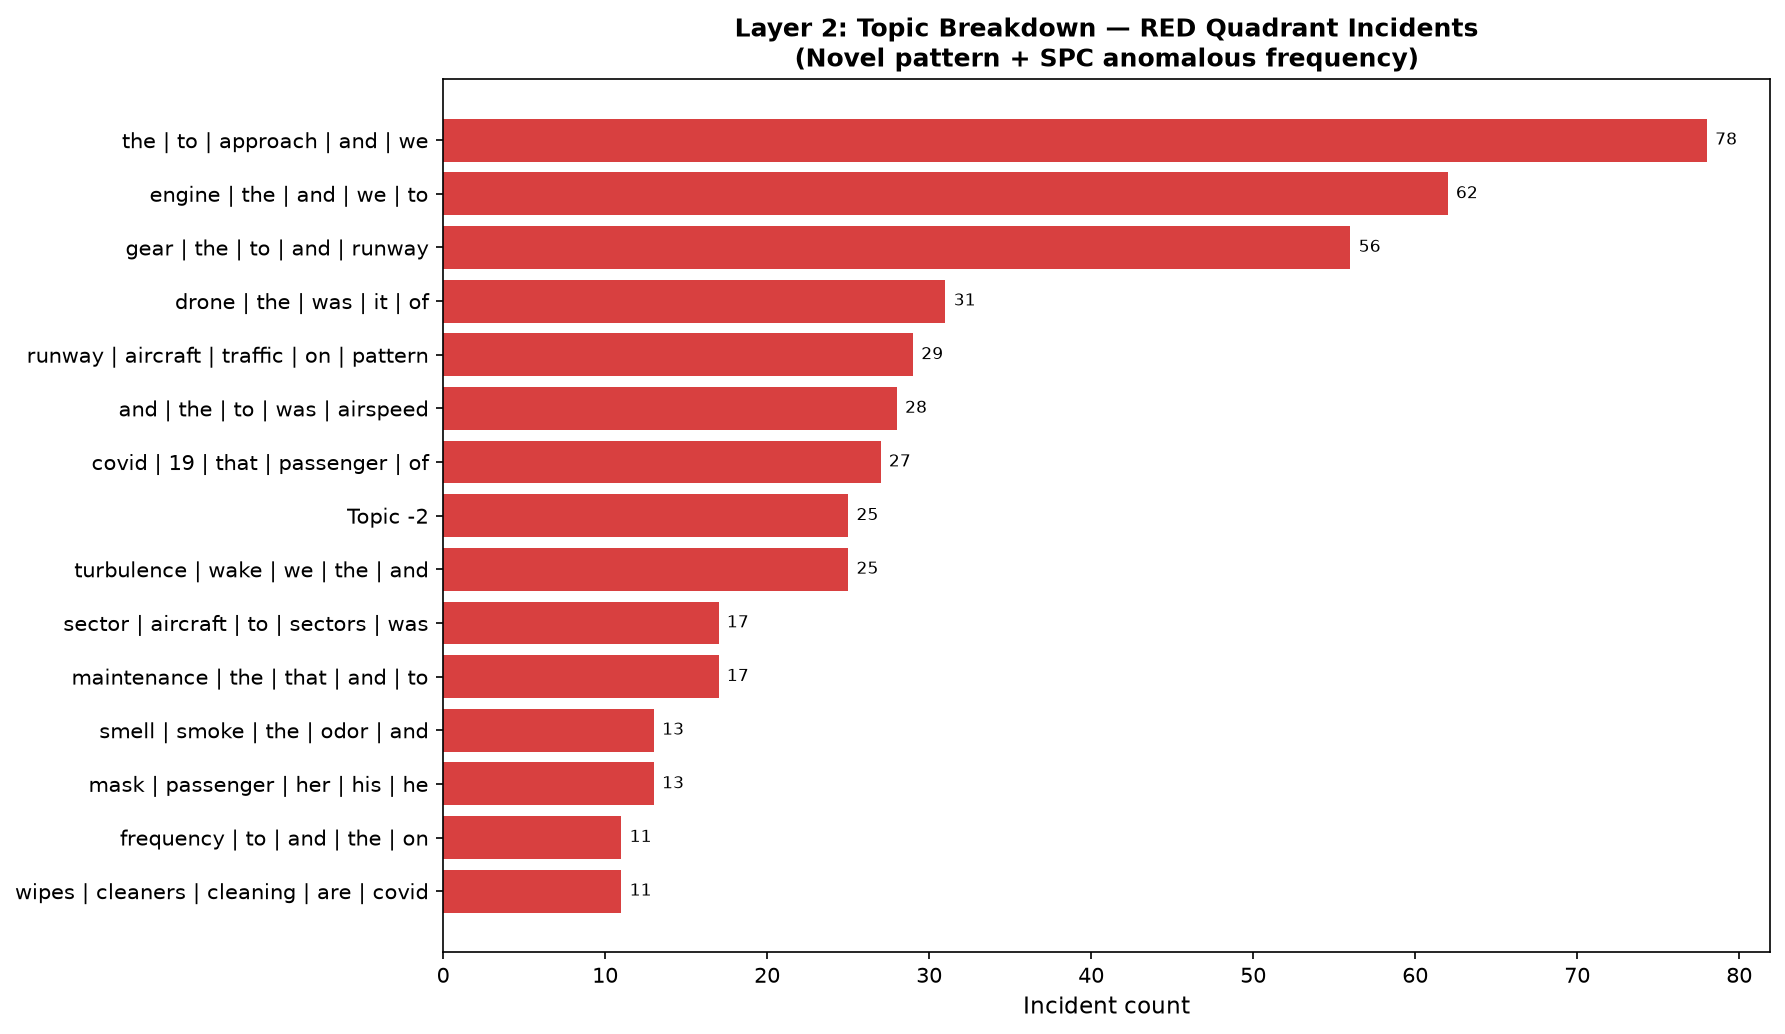

In [9]:
display(Image('../outputs/figures/layer2_red_topics.png'))

In [10]:
# Cross-tab: topic vs quadrant for top 10 topics
top10_ids = asrs_valid['topic_id'].value_counts().head(10).index.tolist()
cross = (
    asrs[asrs['topic_id'].isin(top10_ids)]
    .groupby(['topic_id', 'quadrant'])['ACN'].count()
    .unstack(fill_value=0)
)
# Add keyword column
cross['keywords'] = cross.index.map(lambda t: kw_map.get(t,'?')[:40])
# Compute RED rate
for col in ['RED','ORANGE','YELLOW','GREEN']:
    if col not in cross.columns:
        cross[col] = 0
cross['RED_rate'] = (cross['RED'] / cross[['RED','ORANGE','YELLOW','GREEN']].sum(axis=1) * 100).round(1)
cross = cross.sort_values('RED_rate', ascending=False)
cross[['keywords','RED','ORANGE','YELLOW','GREEN','RED_rate']]

quadrant,keywords,RED,ORANGE,YELLOW,GREEN,RED_rate
topic_id,,,,,,
9,"drone, the, was, it, of, uas, my, airspa",31,177,127,472,3.8
1,"the, to, approach, and, we, was, aircraf",78,1109,133,2077,2.3
2,"gear, the, to, and, runway, landing, was",56,950,81,1893,1.9
0,"engine, the, and, we, to, was, of, at",62,1212,72,2083,1.8
6,"maintenance, the, that, and, to, was, me",17,443,22,639,1.5
5,"turbulence, wake, we, the, and, to, of,",25,465,58,1086,1.5
3,"runway, aircraft, traffic, on, pattern,",29,778,69,1884,1.1
4,"smell, smoke, the, odor, and, to, flight",13,926,15,1240,0.6
7,"brake, the, tug, parking, push, brakes,",4,275,5,739,0.4


---
## Layer 2 Summary

| Finding | Detail |
| --- | --- |
| **Topics discovered** | 40 distinct semantic clusters from 43,829 narratives |
| **GNSS validation** | Topic 12 (gps · jamming · navigation · anp) independently confirms Layer 1 CUSUM alarm |
| **2024–2025 surge** | Topic 12 grew from ~40/yr pre-2023 to 126 (2024) and 118 (2025) — 2.5–3× baseline |
| **Noise** | 37.4% HDBSCAN noise; acceptable given the heterogeneous nature of ASRS reports |
| **RED quadrant topics** | Drone/UAS encounters (Topic 9) and approach/traffic conflicts (Topic 1) have highest RED rates |

**Layer 2 → Layer 3 handoff:**  
Layer 2 adds `topic_id` and `topic_label` to every incident. Layer 3 ignores these columns and operates independently on raw narratives — its rule-based risk scorer provides a third, orthogonal signal. The three signals (quadrant, topic, risk score) together populate the Layer 4 RAG metadata.